#Redução de dimensionalidade

Feature extraction -> encontrando relações mais fortes entre as features de forma que elas sejam reduzidas às mínimas features que representam os dados. Algoritmo não supervisionado, trabalha diretamente na matriz de features, sem necessitar de um target.

Como saída, temos uma matriz que pode ter dimensão reduzida em colunas, em que as colunas são **linearmente independentes**.



PCA - Principal Component Analysis

Algoritmo mais comum para realizar a redução de dimensionalidade.

Acha as direções de maior variabilidade nos dados de alta dimensão, e então projeta os dados em uma dimensão menor dependente destas direções, retendo a maioria das informações.



Resumo do passo a passo:

 - Realize a escala dos dados e centraliza;
 - Encontre os autovetores e autovalores da matriz de covariância ou matriz de correlação, ou realize o Single Value Decomposition (SVD);
 - Ordene os autovalores do maior para o menor. Selecione os k maiores para redução da dimensionalidade (veja que k deve ser menor que d - dimensão inicial dos dados) -> por isso que se retém a **maioria** das informações, mas não necessariamente todas;
 - Construa a matriz de projeção W, a partir os autovalores selecionados e dos autovetores correspondentes;
 - Realize a transformação linear da matriz de features X para a nova matriz X_nova utilizando W.


 https://www.youtube.com/watch?v=FgakZw6K1QQ

In [1]:
#Imports básicos + visualização

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
#from matplotlib.colors import ListedColormap
import seaborn as sns
import plotly as py
import plotly.graph_objs as go

In [2]:
#Imports Sklearn

#from sklearn import tree

#Preprocessamento

#from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Regressão

from sklearn.linear_model import LinearRegression
#from sklearn.tree import DecisionTreeRegressor
#from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

#Classificação

#from sklearn.tree import DecisionTreeClassifier
#from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

#Avaliação e otimização

#from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

#from sklearn.model_selection import cross_val_score
#from sklearn.model_selection import GridSearchCV

#Clustering

from sklearn.cluster import KMeans
#from sklearn.cluster import AgglomerativeClustering

#Dimensionality Reduction

from sklearn.decomposition import PCA

In [3]:
path = 'https://raw.githubusercontent.com/OrlandoIFPR/ml2/refs/heads/main/Dataframes/'

In [4]:
dataset = pd.read_csv(path+ 'Mall_Customers.csv') #Kaggle https://www.kaggle.com/code/kushal1996/customer-segmentation-k-means-analysis/data

dataset.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
X = dataset.iloc[:, 1:5]

X = np.array(ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [0])], remainder='passthrough').fit_transform(X))

X = X[:,1:5]

X = pd.DataFrame(X,columns=['Male?','Age','Annual Income (k$)','Spending Score (1-100)'])

X


,Male?,Age,Annual Income (k$),Spending Score (1-100)
0,1.0,19.0,15.0,39.0
1,1.0,21.0,15.0,81.0
2,0.0,20.0,16.0,6.0
3,0.0,23.0,16.0,77.0
4,0.0,31.0,17.0,40.0
...,...,...,...,...
195,0.0,35.0,120.0,79.0
196,0.0,45.0,126.0,28.0
197,1.0,32.0,126.0,74.0
198,1.0,32.0,137.0,18.0


In [6]:
sc = StandardScaler()
X = sc.fit_transform(X)

In [15]:
pca = PCA(n_components = 2)
X_novo = pca.fit_transform(X)

In [17]:
print(pca.components_)
print(pca.explained_variance_)
print(pca.explained_variance_ratio_)
print(pca.explained_variance_/sum(pca.explained_variance_))


[[ 0.23430156  0.68790025 -0.00608217 -0.68691996]
 [ 0.62688553 -0.10368955  0.7652519   0.10321115]]
[1.35437369 1.05449828]
[0.33690046 0.26230645]
[0.56224395 0.43775605]


In [18]:
X_novo[:10]

array([[-0.40638272, -0.52071363],
       [-1.42767287, -0.3673102 ],
       [ 0.05076057, -1.89406774],
       [-1.6945131 , -1.63190805],
       [-0.31310838, -1.81048272],
       [-1.71744627, -1.59926418],
       [ 0.79082112, -1.94727112],
       [-2.14832159, -1.50537369],
       [ 2.77428623, -0.88298767],
       [-1.21629477, -1.61640464]])

In [19]:
kmeans = KMeans(n_clusters = 2, init = 'random', random_state = 42)
y_kmeans = kmeans.fit_predict(X_novo)



In [20]:
df_novo = pd.DataFrame(X_novo, columns = ['PC1','PC2'])
df_novo['cluster'] = y_kmeans

df_novo


,PC1,PC2,cluster
0,-0.406383,-0.520714,1
1,-1.427673,-0.367310,1
2,0.050761,-1.894068,0
3,-1.694513,-1.631908,1
4,-0.313108,-1.810483,1
...,...,...,...
195,-1.179572,1.324568,1
196,0.672751,1.221061,0
197,-0.723719,2.765010,1
198,0.767096,2.861930,0


Text(0, 0.5, 'PC2')

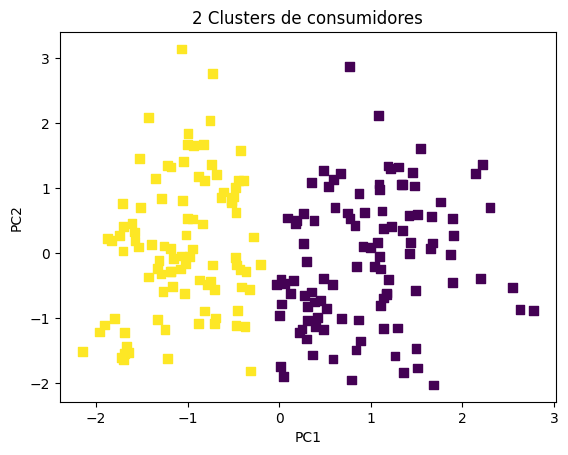

In [21]:
x = np.array(df_novo['PC1'])
y = np.array(df_novo['PC2'])

plt.scatter(x,y, marker="s", c=df_novo["cluster"], s=40)

plt.title('2 Clusters de consumidores')
plt.xlabel('PC1')
plt.ylabel('PC2')

In [22]:
print(pca.components_)

[[ 0.23430156  0.68790025 -0.00608217 -0.68691996]
 [ 0.62688553 -0.10368955  0.7652519   0.10321115]]


`PC1 = 0.234*Male? + 0.688*Age -0.006*(Annual Income)-0.687*(Spending Score)`

`PC2 = 0.627*Male? - 0.104*Age +0.765*(Annual Income)+0.103*(Spending Score)`

Agora vamos pensar no problema de um jeito diferente. Vamos dizer que queremos descobrir o spending score de uma pessoa, baseado em seu gênero, sua idade e seu ganho anual em dólares. Agora temos um problema em que PCA pode fazer mais sentido!

In [24]:
X2_df = dataset.iloc[:, 1:4]
X2_v = dataset.iloc[:, 1:4].values
y2 = dataset.iloc[:,-1]
print(X2_df)
print(y2)

     Gender  Age  Annual Income (k$)
0      Male   19                  15
1      Male   21                  15
2    Female   20                  16
3    Female   23                  16
4    Female   31                  17
..      ...  ...                 ...
195  Female   35                 120
196  Female   45                 126
197    Male   32                 126
198    Male   32                 137
199    Male   30                 137

[200 rows x 3 columns]
0      39
1      81
2       6
3      77
4      40
       ..
195    79
196    28
197    74
198    18
199    83
Name: Spending Score (1-100), Length: 200, dtype: int64


In [25]:
X2_v = np.array(ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [0])], remainder='passthrough').fit_transform(X2_v))

X2_v = X2_v[:,1:4]

X2_df = pd.DataFrame(X2_v,columns=['Male?','Age','Annual Income (k$)'])

X2_df


,Male?,Age,Annual Income (k$)
0,1.0,19,15
1,1.0,21,15
2,0.0,20,16
3,0.0,23,16
4,0.0,31,17
...,...,...,...
195,0.0,35,120
196,0.0,45,126
197,1.0,32,126
198,1.0,32,137


In [26]:
X_train, X_test, y_train, y_test = train_test_split(X2_df, y2, test_size = 0.2, random_state = 0)

In [27]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [28]:
X_train[:10]

array([[ 1.16316   , -1.31358807,  0.4711306 ],
       [-0.85972695,  0.307473  , -0.48064839],
       [-0.85972695,  0.44843483, -1.24207159],
       [ 1.16316   , -1.38406899,  0.12849016],
       [-0.85972695, -0.18589342,  1.00412684],
       [-0.85972695,  1.08276307, -0.51871955],
       [ 1.16316   ,  1.78757223, -1.58471203],
       [ 1.16316   , -0.89070257, -0.25222143],
       [-0.85972695,  0.87132032,  0.24270364],
       [-0.85972695, -0.46781708,  0.58534408]])

In [29]:
regressor1 = LinearRegression()
regressor1.fit(X_train, y_train)

LinearRegression()

In [31]:
y_pred = regressor1.predict(X_test)
mae=mean_absolute_error(y_test, y_pred)
print(mae)

21.668637850146826


In [39]:
pca = PCA(n_components=3)
X_trainpc = pca.fit_transform(X_train)
X_testpc = pca.transform(X_test)

In [40]:
regressor2 = LinearRegression()
regressor2.fit(X_trainpc, y_train)

LinearRegression()

In [41]:
y_predpc = regressor2.predict(X_testpc)
maepc=mean_absolute_error(y_test, y_predpc)
print(maepc)

21.66863785014683


In [42]:
print(pca.components_)
print(pca.explained_variance_ratio_)

[[ 0.69688214  0.71578696 -0.04476956]
 [ 0.33196866 -0.26660752  0.90482995]
 [-0.63572958  0.64542192  0.42341286]]
[0.34245239 0.33586145 0.32168616]


In [43]:
X_trainpc_df=pd.DataFrame(X_trainpc)

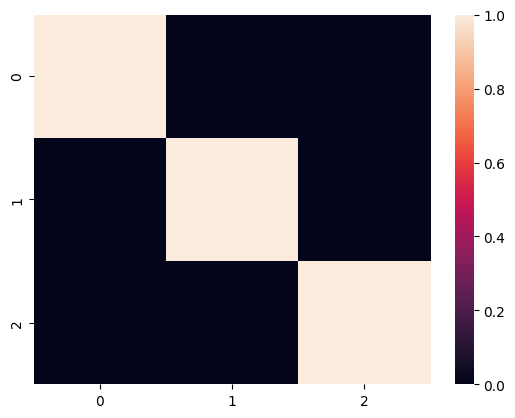

In [44]:
corr = X_trainpc_df.corr()
sns.heatmap(corr);

In [45]:
X_train_df=pd.DataFrame(X_train)

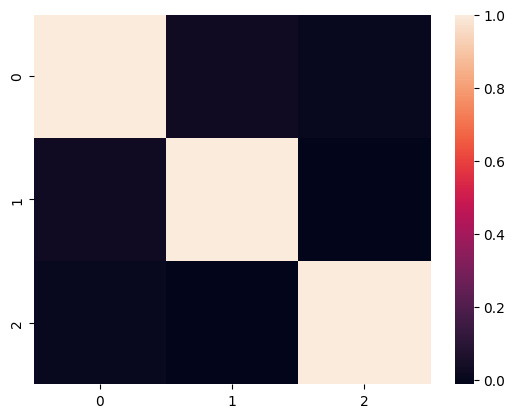

In [46]:
corr = X_train_df.corr()
sns.heatmap(corr);

#Melbourne

In [47]:
dataset = pd.read_csv(path+ 'melb_data.csv')
dataset.head()

,Unnamed: 0,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,5,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,6,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [50]:
dataset = dataset.dropna(axis=0) #retira as linhas com NaN

features = ['Rooms', 'Bathroom', 'Landsize', 'Distance', 'BuildingArea','Car','YearBuilt']

#features = ['Distance', 'BuildingArea','YearBuilt','Postcode']

X = dataset[features]
y = dataset.Price

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 1/3, random_state = 0)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

regressor2 = LinearRegression()
regressor2.fit(X_train, y_train)

y_pred = regressor2.predict(X_test)

mean_absolute_error(y_test, y_pred)/y_test.mean()


0.27965723911541335

In [51]:
regressor3 = SVR(kernel = 'rbf')
regressor3.fit(X_train, y_train)
regressor4 = SVR(kernel = 'linear')
regressor4.fit(X_train, y_train)

y_pred3 = regressor3.predict(X_test)
print(mean_absolute_error(y_test, y_pred3)/y_test.mean())

y_pred4 = regressor4.predict(X_test)
print(mean_absolute_error(y_test, y_pred4)/y_test.mean())

0.43933724377362726
0.4367914300982478


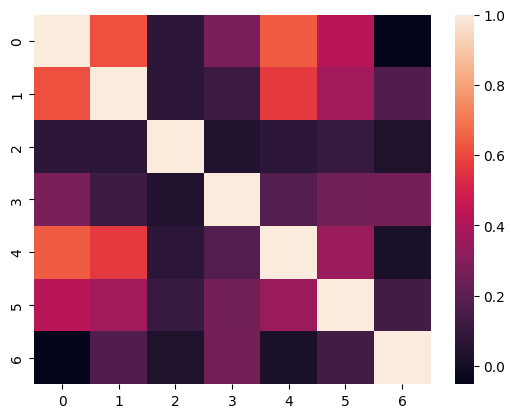

In [52]:
X_train = pd.DataFrame(X_train)
corr = X_train.corr()
sns.heatmap(corr);

In [53]:
pca = PCA()
X_trainpc = pca.fit_transform(X_train)
X_testpc = pca.transform(X_test)

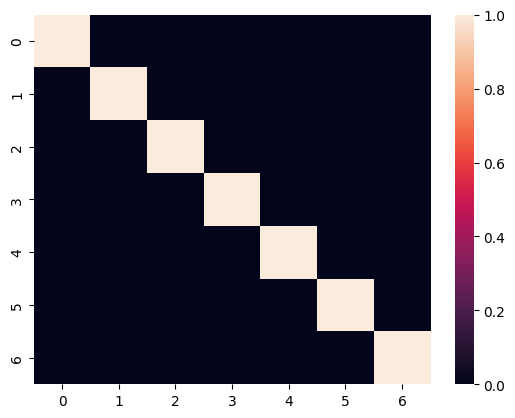

In [54]:
X_trainpc = pd.DataFrame(X_trainpc)
corr = X_trainpc.corr()
sns.heatmap(corr);

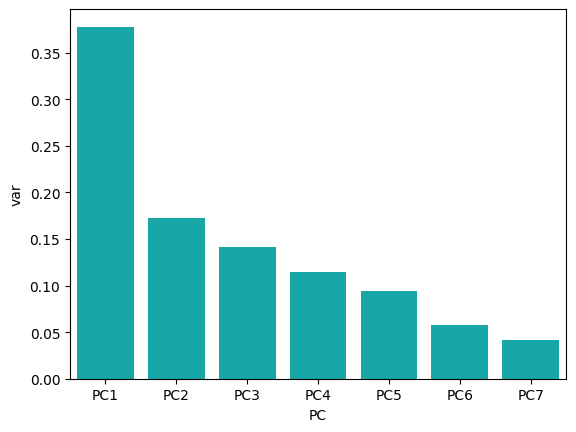

In [55]:
df_var_explained = pd.DataFrame({'var':pca.explained_variance_ratio_,'PC':['PC'+str(i) for i in range (1,8)]})
sns.barplot(x='PC',y="var", data=df_var_explained, color="c");

In [60]:
pca = PCA(n_components=5)
X_trainpc = pca.fit_transform(X_train)
X_testpc = pca.transform(X_test)

In [61]:
regressor2 = LinearRegression()
regressor2.fit(X_trainpc, y_train)

LinearRegression()

In [62]:
y_predpc = regressor2.predict(X_testpc)
maepc=mean_absolute_error(y_test, y_predpc)
print(maepc)

305063.18184805906


In [63]:
mean_absolute_error(y_test, y_predpc)/y_test.mean()

0.28064269879804954

In [64]:
regressor5 = SVR(kernel = 'rbf')
regressor5.fit(X_trainpc, y_train)
regressor6 = SVR(kernel = 'linear')
regressor6.fit(X_trainpc, y_train)

y_pred5 = regressor5.predict(X_testpc)
print(mean_absolute_error(y_test, y_pred5)/y_test.mean())

y_pred6 = regressor6.predict(X_testpc)
print(mean_absolute_error(y_test, y_pred6)/y_test.mean())

0.43932051153656954
0.43679172588943216


#E com um dataset com alta dimensão?

In [65]:
df = pd.read_csv(path+ 'vehicle.csv')
df.head()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48,83,178,72,10,162,42,20,159,176,379,184,70,6,16,187,197,van
1,91,41,84,141,57,9,149,45,19,143,170,330,158,72,9,14,189,199,van
2,104,50,106,209,66,10,207,32,23,158,223,635,220,73,14,9,188,196,saab
3,93,41,82,159,63,9,144,46,19,143,160,309,127,63,6,10,199,207,van
4,85,44,70,205,103,52,149,45,19,144,241,325,188,127,9,11,180,183,bus


In [66]:
X = df.iloc[:, :-1]
y = df.iloc[:,-1]

from sklearn.preprocessing import LabelEncoder

y = LabelEncoder().fit_transform(y)
y

array([3, 3, 2, 3, 0, 0, 0, 3, 3, 2, 3, 2, 0, 3, 0, 1, 3, 0, 2, 1, 0, 3,
       0, 0, 2, 3, 2, 2, 0, 2, 3, 2, 1, 1, 1, 3, 0, 3, 2, 0, 1, 3, 3, 2,
       2, 3, 3, 0, 3, 2, 2, 2, 1, 0, 0, 3, 2, 3, 1, 3, 1, 1, 3, 0, 0, 1,
       0, 1, 3, 0, 1, 1, 1, 1, 3, 1, 2, 2, 0, 0, 0, 0, 3, 1, 0, 0, 3, 3,
       0, 1, 2, 1, 2, 3, 0, 1, 2, 0, 1, 0, 0, 3, 3, 3, 0, 2, 1, 1, 0, 0,
       3, 3, 1, 1, 3, 3, 1, 2, 0, 0, 2, 3, 3, 2, 3, 3, 0, 0, 3, 0, 2, 2,
       2, 3, 1, 3, 3, 3, 2, 3, 2, 0, 1, 0, 1, 1, 3, 0, 2, 3, 2, 0, 1, 2,
       3, 0, 1, 3, 2, 1, 1, 1, 2, 2, 1, 1, 2, 2, 0, 3, 1, 0, 3, 0, 3, 0,
       1, 0, 0, 3, 2, 1, 0, 2, 2, 0, 0, 1, 1, 1, 1, 3, 2, 0, 2, 0, 2, 0,
       0, 0, 3, 2, 1, 1, 3, 3, 1, 0, 0, 1, 1, 3, 0, 0, 1, 1, 2, 1, 0, 3,
       1, 3, 0, 0, 2, 3, 2, 3, 2, 2, 3, 2, 0, 2, 3, 3, 0, 0, 1, 0, 1, 1,
       0, 2, 3, 3, 0, 2, 1, 2, 3, 1, 3, 0, 3, 2, 2, 1, 2, 1, 2, 2, 3, 3,
       2, 0, 0, 2, 3, 3, 0, 2, 3, 3, 0, 0, 0, 1, 2, 0, 1, 0, 0, 2, 3, 2,
       0, 3, 1, 2, 3, 3, 0, 3, 0, 0, 0, 2, 2, 0, 2,

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

0.6882352941176471


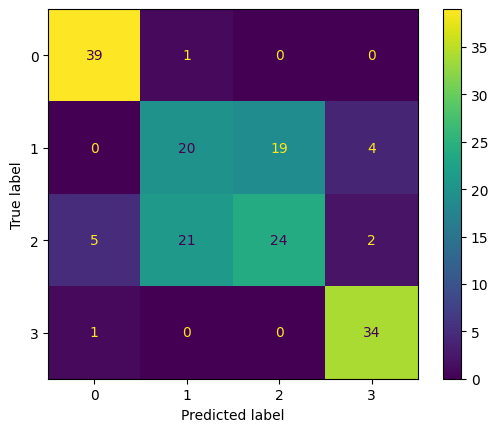

In [68]:
classifier = KNeighborsClassifier(n_neighbors = 7, metric = 'minkowski', p = 5) #minkowski feito com p = 2 é a distância euclidiana
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
print(accuracy_score(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot();

In [69]:
classifier3 = SVC(kernel = 'linear', random_state = 0)
classifier3.fit(X_train, y_train)
y_pred3 = classifier3.predict(X_test)
print(accuracy_score(y_test, y_pred3))
classifier4 = SVC(kernel = 'rbf', random_state = 0)
classifier4.fit(X_train, y_train)
y_pred4 = classifier4.predict(X_test)
print(accuracy_score(y_test, y_pred4))

0.788235294117647
0.7352941176470589


In [70]:
pca = PCA()
X_trainpc = pca.fit_transform(X_train)
X_testpc = pca.transform(X_test)

In [71]:
df_var_explained = pd.DataFrame({'var':pca.explained_variance_ratio_,'PC':['PC'+str(i) for i in range (1,19)]})
df_var_explained.shape


(18, 2)

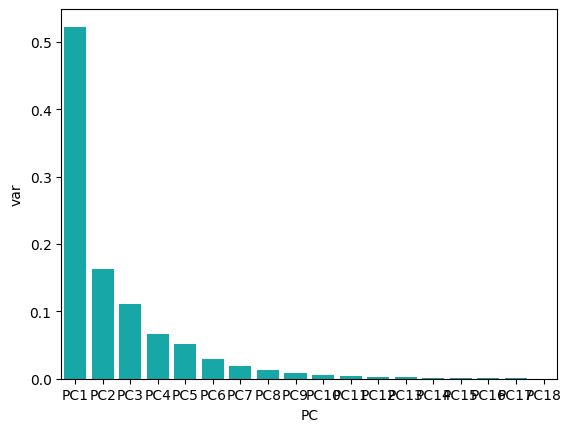

In [72]:
sns.barplot(x='PC',y="var", data=df_var_explained, color="c");

In [80]:
pca2 = PCA(n_components=1)
X_trainpc2 = pca.fit_transform(X_train)
X_testpc2 = pca.transform(X_test)

0.6647058823529411


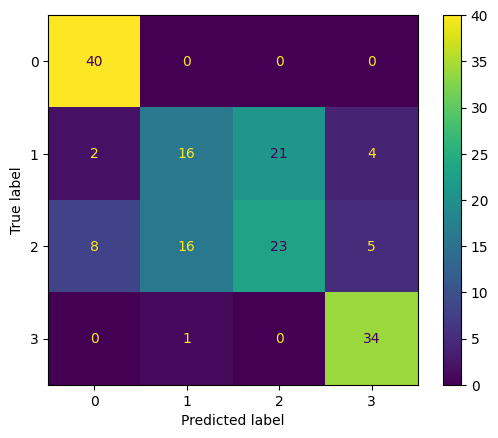

In [81]:
classifier = KNeighborsClassifier(n_neighbors = 7, metric = 'minkowski', p = 5) #minkowski feito com p = 2 é a distância euclidiana
classifier.fit(X_trainpc2, y_train)
y_predpc2 = classifier.predict(X_testpc2)
print(accuracy_score(y_test, y_predpc2))

cm = confusion_matrix(y_test, y_predpc2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot();

In [82]:
classifier5 = SVC(kernel = 'linear', random_state = 0)
classifier5.fit(X_trainpc2, y_train)
y_pred5 = classifier5.predict(X_testpc2)
print(accuracy_score(y_test, y_pred5))

0.788235294117647


In [83]:
pca2 = PCA(n_components=5)
X_trainpc2 = pca.fit_transform(X_train)
X_testpc2 = pca.transform(X_test)

0.6647058823529411


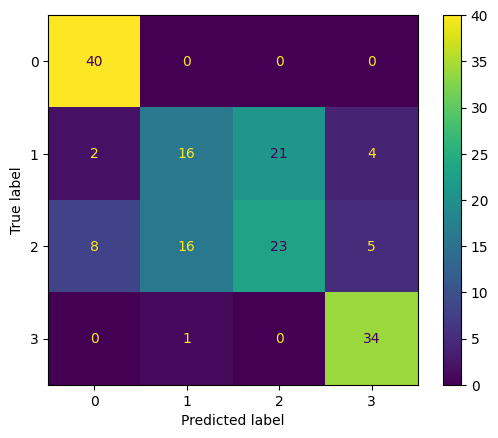

In [84]:
classifier = KNeighborsClassifier(n_neighbors = 7, metric = 'minkowski', p = 5) #minkowski feito com p = 2 é a distância euclidiana
classifier.fit(X_trainpc2, y_train)
y_predpc2 = classifier.predict(X_testpc2)
print(accuracy_score(y_test, y_predpc2))

cm = confusion_matrix(y_test, y_predpc2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot();


0.788235294117647


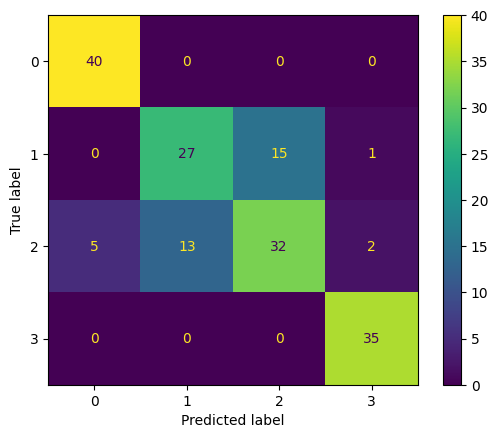

In [54]:
classifier = SVC(kernel = 'linear', random_state = 0)
classifier.fit(X_trainpc2, y_train)
y_predpc2 = classifier.predict(X_testpc2)
print(accuracy_score(y_test, y_predpc2))

cm = confusion_matrix(y_test, y_predpc2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot();

#Caso em que PCA aumenta a acurácia:

http://citeseerx.ist.psu.edu/viewdoc/download?doi=10.1.1.74.8032&rep=rep1&type=pdf

#Visualização dos PCs e a intuição de PCA



https://plotly.com/python/pca-visualization/

https://setosa.io/ev/principal-component-analysis/

https://www.youtube.com/watch?v=FgakZw6K1QQ